# GMM from scratch

## Setup

In [93]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# from scipy.stats import norm
from scipy.stats import multivariate_normal
from scipy.fftpack import fft
from scipy.interpolate import make_splrep
from scipy.special import logsumexp

# from sklearn.mixture import GaussianMixture
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# from tslearn.preprocessing import TimeSeriesScalerMeanVariance
# from tslearn.utils import to_time_series_dataset
from tsfresh.feature_extraction import feature_calculators as feat_calc

import pyLasaDataset as lasa
# from hmmlearn import hmm
# from tqdm.auto import tqdm

### Hyperparameters

In [94]:
# seed = 0
seed = 42
seq_length = 100
rng = np.random.default_rng(seed)
window_size = 10
window_step = 5

## Data

In [95]:
# series1 = rng.normal(loc=0, scale=1, size=(seq_length, 2))
# series2 = rng.normal(loc=5, scale=1, size=(seq_length, 2))
# series3 = rng.normal(loc=-3, scale=1, size=(seq_length, 2))
# data = np.stack([series1, series2, series3])
# data.shape

In [96]:
means = np.array(
    [
        [1, 3],
        [3, 1],
        [2.5, 2.5],
    ]
)
covs = np.eye(2) * 0.08
data = np.ones((means.shape[0], seq_length, 2)) * np.nan
for idx in range(means.shape[0]):
    data[idx, :, :] = rng.multivariate_normal(
        mean=means[idx, :], cov=covs, size=(seq_length)
    )
data.shape

(3, 100, 2)

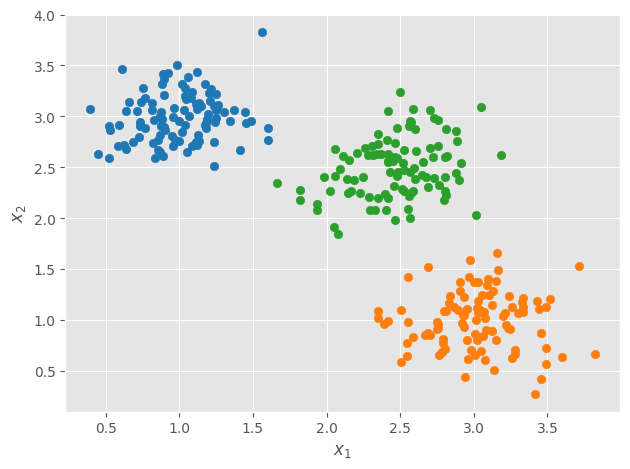

In [97]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots()
    for idx in range(data.shape[0]):
        ax.scatter(data[idx, :, 0], data[idx, :, 1], color=cmap[idx])
    ax.set_xlabel(f"$x_1$")
    ax.set_ylabel(f"$x_2$")
    fig.tight_layout()
    plt.show()

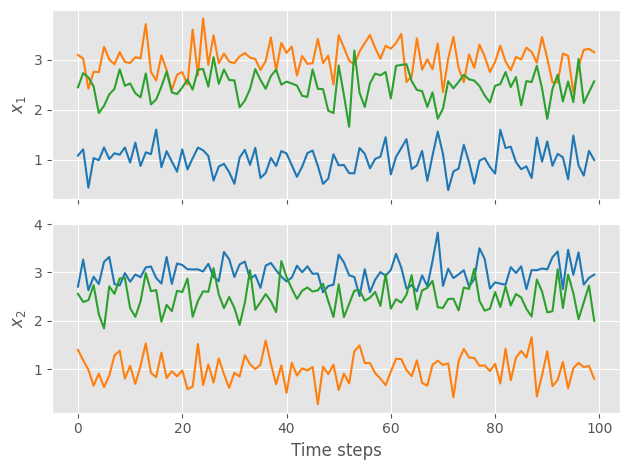

In [98]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots(data.shape[-1], 1, sharex=True)
    for idx in range(data.shape[-1]):
        for jdx in range(data.shape[0]):
            ax[idx].plot(data[jdx, :, idx], c=cmap[jdx])
        ax[idx].set_ylabel(f"$x_{idx + 1}$")
    ax[idx].set_xlabel("Time steps")
    fig.tight_layout()
    plt.show()

## Preprocessing & feature engineering

In [99]:
# dataset = to_time_series_dataset(data)
# dataset.shape

In [100]:
# scaler = TimeSeriesScalerMeanVariance()
# data_scaled = np.squeeze(scaler.fit_transform(data))
# data_scaled.shape

In [101]:
def sliding_window(series, window_size, step):
    windows = []
    for i in range(0, len(series) - window_size + 1, step):
        windows.append(series[i : i + window_size])
    return np.array(windows)

In [102]:
windows = []
for idx in range(data.shape[0]):
    data_sc_i = data[idx, :, :]
    windows.append(
        sliding_window(series=data_sc_i, window_size=window_size, step=window_step)
    )
windows = np.array(windows)
windows.shape

(3, 19, 10, 2)

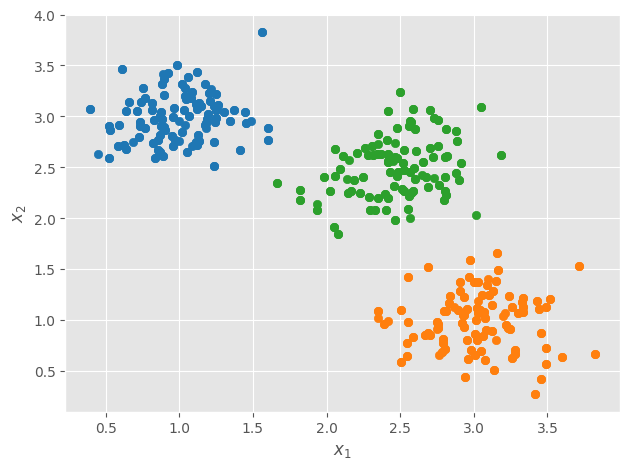

In [103]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots()
    for idx in range(windows.shape[0]):
        for jdx in range(windows.shape[1]):
            ax.scatter(
                windows[idx, jdx, :, 0], windows[idx, jdx, :, 1], color=cmap[idx]
            )
    ax.set_xlabel(f"$x_1$")
    ax.set_ylabel(f"$x_2$")
    fig.tight_layout()
    plt.show()

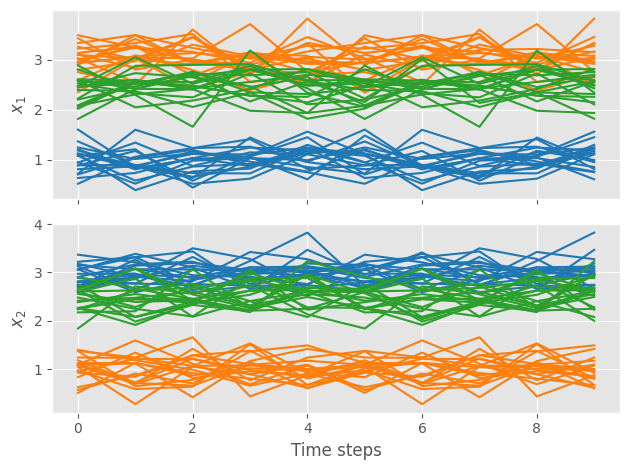

In [104]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots(windows.shape[-1], 1, sharex=True)
    for idx in range(windows.shape[-1]):
        for jdx in range(windows.shape[0]):
            for kdx in range(windows.shape[1]):
                ax[idx].plot(windows[jdx, kdx, :, idx], c=cmap[jdx])
        ax[idx].set_ylabel(f"$x_{idx + 1}$")
    ax[idx].set_xlabel("Time steps")
    fig.tight_layout()
    plt.show()

In [105]:
def loop_on_col(arr, funct, *args, **kwargs):
    res = []
    for col in range(arr.shape[1]):
        res.append(funct(arr[:, col], *args, **kwargs))
    return res

In [106]:
def extract_features(windows, lag=5, bins=10):
    features = []
    for win in windows:
        feats = [
            # np.mean(win),
            # np.std(win),
            # np.min(win),
            # np.max(win),
            # np.median(win),
            # np.percentile(win, 25),
            # np.percentile(win, 75),
            # *np.abs(fft(win)).flatten()[:5]
            *loop_on_col(arr=win, funct=feat_calc.abs_energy),
            feat_calc.absolute_sum_of_changes(win),
            feat_calc.autocorrelation(x=win, lag=lag),
            *loop_on_col(arr=win, funct=feat_calc.benford_correlation),
            # feat_calc.binned_entropy(x=win, max_bins=bins),
            feat_calc.c3(x=win, lag=lag),
            *loop_on_col(arr=win, funct=feat_calc.cid_ce, normalize=True),
            # *loop_on_col(arr=win, funct=feat_calc.fourier_entropy, bins=bins),
            *loop_on_col(arr=win, funct=feat_calc.kurtosis),
            *loop_on_col(arr=win, funct=feat_calc.lempel_ziv_complexity, bins=bins),
            *loop_on_col(arr=win, funct=feat_calc.longest_strike_above_mean),
            *loop_on_col(arr=win, funct=feat_calc.longest_strike_below_mean),
            feat_calc.mean_abs_change(win),
            *feat_calc.mean_change(win),
            *feat_calc.mean_second_derivative_central(win),
            *loop_on_col(
                arr=win,
                funct=feat_calc.percentage_of_reoccurring_datapoints_to_all_datapoints,
            ),
            *loop_on_col(
                arr=win, funct=feat_calc.percentage_of_reoccurring_values_to_all_values
            ),
            feat_calc.ratio_value_number_to_time_series_length(win),
            feat_calc.root_mean_square(win),
            feat_calc.sample_entropy(win),
            *loop_on_col(arr=win, funct=feat_calc.skewness),
            feat_calc.time_reversal_asymmetry_statistic(x=win, lag=lag),
            feat_calc.variation_coefficient(win),
        ]
        features.append(feats)
    return np.array(features)

In [107]:
features = []
for idx in range(windows.shape[0]):
    window_i = windows[idx, :, :]
    features.append(extract_features(window_i))
features = np.array(features)
features.shape

(3, 19, 33)

In [108]:
classes_gt = np.array(
    [np.ones(features.shape[1]) * idx for idx in range(features.shape[0])]
).flatten()
classes_gt

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2.])

In [109]:
feat_mat = features.reshape(features.shape[0] * features.shape[1], features.shape[2])
feat_mat = pd.DataFrame(feat_mat)
feat_mat

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,11.571485,86.341783,18.752872,1.896223,0.833662,0.310942,13.308673,4.772010,4.906791,6.100929,...,0.0,0.0,0.0,1.0,2.212615,0.810930,-2.258800,0.562416,0.0,0.485177
1,12.709689,89.755904,18.707712,1.915477,0.807168,0.298659,14.080955,5.856260,3.712232,-0.400289,...,0.0,0.0,0.0,1.0,2.263466,0.599621,-0.188444,0.249853,0.0,0.462235
2,12.265597,89.192342,19.000588,1.867807,0.579097,0.298659,13.917389,4.974479,5.302902,0.647201,...,0.0,0.0,0.0,1.0,2.252309,0.949081,0.928191,0.500174,0.0,0.479429
3,12.378357,91.999116,19.420928,1.920861,0.695527,0.182761,14.602032,4.560505,5.329494,0.592182,...,0.0,0.0,0.0,1.0,2.284485,0.622530,0.688056,-0.209876,0.0,0.482678
4,9.853358,96.168471,21.260276,1.942633,0.637557,0.136829,15.368119,3.800681,4.320406,-0.893521,...,0.0,0.0,0.0,1.0,2.302410,0.530628,-0.322555,0.334846,0.0,0.530708
5,8.856292,94.721789,21.585619,1.868656,0.502537,0.271055,14.816125,4.172537,4.592196,-0.804903,...,0.0,0.0,0.0,1.0,2.275721,0.810930,-0.300191,0.352045,0.0,0.552171
6,9.364631,90.777094,20.692567,1.980021,0.686050,0.271055,14.188646,4.451874,4.378812,-1.018134,...,0.0,0.0,0.0,1.0,2.237652,0.720546,-0.417676,-0.453712,0.0,0.534181
7,8.757084,89.922551,20.778110,1.951309,0.432664,0.230027,13.897005,3.530815,3.810831,-1.469490,...,0.0,0.0,0.0,1.0,2.221257,0.870828,-0.071184,-0.663277,0.0,0.538643
8,8.651349,84.242581,19.952833,1.938033,0.453579,0.310942,12.555451,3.688634,3.159698,-1.361498,...,0.0,0.0,0.0,1.0,2.155156,0.664976,-0.331227,-0.261049,0.0,0.535612
9,8.304995,84.357609,20.108284,1.945571,0.247995,0.311386,12.663388,3.955263,3.578344,-1.009246,...,0.0,0.0,0.0,1.0,2.152471,0.733969,0.155355,0.348645,0.0,0.547335


In [110]:
# scaler = StandardScaler()
# feat_mat = scaler.fit_transform(feat_mat)
# feat_mat = pd.DataFrame(feat_mat)
# feat_mat

## GMM clustering

In [111]:
def e_step(X, pi_mixing_prior, mu, Sigma, seed=None):
    # eps = np.finfo(float).eps
    N, K = X.shape[0], pi_mixing_prior.shape[0]
    # gamma_resp = np.zeros((N, K))
    log_probs = np.zeros((N, K))

    for k in range(K):
        # gamma_resp[:, k] = pi_mixing_prior[k] * multivariate_normal(mean=mu[k], cov=Sigma[k], allow_singular=False, seed=seed).pdf(X)
        log_probs[:, k] = np.log(pi_mixing_prior[k]) + multivariate_normal.logpdf(
            x=X, mean=mu[k], cov=Sigma[k], allow_singular=False
        )
    log_norm = logsumexp(log_probs, axis=1, keepdims=True)
    gamma_resp = np.exp(log_probs - log_norm)

    # # Normalize to get responsibilities
    # W_sum = gamma_resp.sum(axis=1, keepdims=True)
    # W_sum[W_sum == 0.0] = eps
    # gamma_resp /= W_sum
    return gamma_resp

In [112]:
def m_step(X, gamma_resp, reg_coef=1e-3):
    N, D = X.shape
    K = gamma_resp.shape[1]
    Nk = gamma_resp.sum(axis=0)  # soft counts

    # Update mixing coefficients
    pi_mixing_prior_new = Nk / N

    # Avoid division by zero
    # eps = np.finfo(float).eps
    # Nk[Nk == 0.0] = eps
    Nk = np.maximum(Nk, reg_coef)

    # Update means
    mu_new = (gamma_resp.T @ X) / Nk[:, None]

    # Update covariances
    Sigma_new = np.zeros((K, D, D))
    for j in range(K):
        diff = X - mu_new[j]

        # # weight each outer product by responsibility
        # Sigma_new[j] = (gamma_resp[:, j][:, None] * diff).T @ diff / Nk[j]

        # # regularization for numerical stability (optional, small jitter)
        # Sigma_new[j] += reg_coef*np.eye(D)

        # Constrain the covariance matrices to be diagonal
        var = (gamma_resp[:, j][:, None] * diff**2).sum(axis=0) / Nk[j]
        Sigma_new[j] = np.diag(var + reg_coef)

    # # Make sure the covariance matrices are symmetric positive definite
    # Sigma_new_spd = np.ones_like(Sigma_new)*np.nan
    # for j in range(K):
    #     # lower_tri = np.linalg.cholesky(Sigma_new[j])  # Cholesky Decomposition
    #     # Sigma_new_spd[j] = lower_tri @ lower_tri.T
    #     Sigma_new_spd[j] = np.linalg.cholesky(Sigma_new[j])  # Cholesky Decomposition
    # Sigma_new = Sigma_new_spd

    # # Make covariance matrices diagonal
    # Sigma_new *= np.eye(D)

    return pi_mixing_prior_new, mu_new, Sigma_new

In [113]:
# def log_likelihood(X, pi_mixing_prior, mu, Sigma, seed=None):
#     eps = np.finfo(float).eps
#     N, K = X.shape[0], pi_mixing_prior.shape[0]
#     comp = np.zeros((N, K))
#     for j in range(K):
#         comp[:, j] = pi_mixing_prior[j] * multivariate_normal(mean=mu[j], cov=Sigma[j], allow_singular=False, seed=seed).pdf(X)

#     # sum over components then take log
#     s = comp.sum(axis=1)
#     s[s == 0.0] = eps
#     return np.sum(np.log(s))


def log_likelihood(X, pi_mixing_prior, mu, Sigma):
    N, K = X.shape[0], pi_mixing_prior.shape[0]
    log_probs = np.zeros((N, K))
    for k in range(K):
        log_probs[:, k] = np.log(pi_mixing_prior[k]) + multivariate_normal.logpdf(
            x=X,
            mean=mu[k],
            cov=Sigma[k],
            allow_singular=False,
        )
    # logsumexp over components, then sum over data points
    return logsumexp(log_probs, axis=1).sum()

In [114]:
def run_EM(X, K_components, max_iter=300, tol=1e-6, reg_coef=1e-3, seed=None):

    # Initialization
    N, D = X.shape
    pi_mixing_prior = np.ones(K_components) / K_components
    # pi_mixing_prior = np.random.uniform(size=K_components)
    # pi_mixing_prior = pi_mixing_prior/pi_mixing_prior.sum()
    # mu = np.random.rand(K_components, D) * 10.0
    kmeans_init = KMeans(n_clusters=K_components, random_state=seed).fit(X=X)
    mu = np.array(kmeans_init.cluster_centers_)
    # Sigma = np.array([np.eye(D) * rng.uniform(low=0, high=0.01, size=D) for _ in range(K_components)])
    Sigma = np.array([np.eye(D) for _ in range(K_components)])

    lls = []
    for it in range(max_iter):
        # E-step
        gamma_resp = e_step(
            X=X, pi_mixing_prior=pi_mixing_prior, mu=mu, Sigma=Sigma, seed=seed
        )

        # M-step
        pi_mixing_prior, mu, Sigma = m_step(
            X=X, gamma_resp=gamma_resp, reg_coef=reg_coef
        )

        # Log-likelihood
        ll = log_likelihood(X=X, pi_mixing_prior=pi_mixing_prior, mu=mu, Sigma=Sigma)
        lls.append(ll)

        # # Visualization every few iterations
        # if it in (0, 1, 2, 4, 9, 14, 19, 24, 29):
        #     plot_gmm(X, mu, Sigma, title=f'GMM Contours — Iteration {it+1}')

        # Convergence check
        if it > 0 and abs(lls[-1] - lls[-2]) < tol:
            print(f"Converged at iteration {it + 1}")
            break

    with plt.style.context("ggplot"):
        fig, ax = plt.subplots()
        ax.plot(lls, marker=".", c="k")
        ax.set_title("Log-likelihood over EM iterations")
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Log-likelihood")
        # ax.set_grid(True, alpha=0.3)
        plt.show()

    labels_pred = np.argmax(gamma_resp, axis=1)
    return mu, Sigma, gamma_resp, labels_pred, pi_mixing_prior

In [115]:
def predict(X, pi_mixing_prior, mu, Sigma, seed=None):
    gamma_resp = e_step(
        X=X, pi_mixing_prior=pi_mixing_prior, mu=mu, Sigma=Sigma, seed=seed
    )
    labels_pred = np.argmax(gamma_resp, axis=1)
    return gamma_resp, labels_pred

In [116]:
# max_iter = 300
# tol = 1e-6
reg_coef = 1e-6
K_components = data.shape[0]

Converged at iteration 2


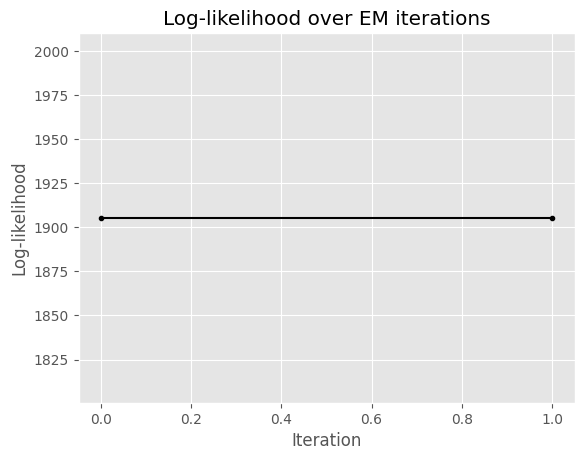

(array([[ 9.23113181e+01,  1.06477868e+01,  2.03016298e+01,
          1.84443862e+00,  2.44327662e-01,  6.03791562e-01,
          1.44704509e+01,  4.58269461e+00,  4.49633733e+00,
          3.35413434e-01,  1.38341567e-01,  7.84210526e-01,
          7.52631579e-01,  2.26315789e+00,  2.73684211e+00,
          2.68421053e+00,  2.52631579e+00,  2.03016298e+00,
          1.30388366e-03, -8.75480816e-03, -1.00819801e-03,
         -1.20500499e-03,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  1.00000000e+00,
          2.26821899e+00,  7.45585365e-01,  1.83529341e-01,
         -5.73401665e-02,  0.00000000e+00,  5.24318039e-01],
        [ 1.05650342e+01,  8.99988951e+01,  1.99485931e+01,
          1.88708881e+00,  5.73343368e-01,  2.65804275e-01,
          1.39818183e+01,  4.43423292e+00,  4.27039786e+00,
         -1.24463274e-01, -3.02886560e-01,  7.84210526e-01,
          7.52631579e-01,  2.47368421e+00,  2.73684211e+00,
          2.73684211e+00,  3.21052632e+

In [117]:
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior = run_EM(
    X=feat_mat.to_numpy(), K_components=K_components, reg_coef=reg_coef, seed=seed
)
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior

In [26]:
# K_components = 3
# gmm = GaussianMixture(n_components=K_components, random_state=seed)
# gmm.fit(feat_mat)
# # labels = gmm.fit_predict(features_scaled)
# clust_labels_pred = gmm.predict(feat_mat)
# proba = gmm.predict_proba(feat_mat)
# # print("Cluster labels (model-based):", labels)
# clust_labels_pred, np.round(proba)

In [27]:
# np.round(gmm.means_), np.round(gmm.covariances_)

In [28]:
# gmm.means_.shape, gmm.covariances_.shape

In [29]:
# with plt.style.context("ggplot"):
#     cmap = plt.colormaps["tab10"].colors
#     fig, ax = plt.subplots()
#     for idx in range(data.shape[0]):
#         ax.scatter(data[idx, :, 0], data[idx, :, 1], color="k", alpha=0.4)
#     ax.set_xlabel(f"$x_1$")
#     ax.set_ylabel(f"$x_2$")

#     # xg, yg = np.meshgrid(np.linspace(-5, 15, 100), np.linspace(-5, 15, 100))
#     # pos = np.dstack((xg, yg))
#     # for jdx in range(K_components):
#     #     rv = rng.multivariate_normal(
#     #         mean=gmm.means_[jdx], cov=gmm.covariances_[jdx]
#     #     )
#     #     # ax.contour(xg, yg, rv.pdf(pos), levels=5, colors=cmap[jdx], alpha=0.8)
#     #     ax.scatter(gmm.means_[jdx, 0], gmm.means_[jdx, 1], c="k")#, color=cmap[jdx], marker="x", s=100)

#     fig.tight_layout()
#     plt.show()

### Metrics

In [30]:
# accu = accuracy_score(y_true=classes_gt, y_pred=clust_labels_pred)
# print(f"Accuracy: {accu}")

In [31]:
print(f"Silhouette: {metrics.silhouette_score(X=feat_mat, labels=clust_labels_pred)}")
print(
    f"Completeness: {metrics.completeness_score(labels_true=classes_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"Fowlkes-Mallows index: {metrics.fowlkes_mallows_score(labels_true=classes_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"Homogeneity: {metrics.homogeneity_score(labels_true=classes_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"Mutual Information: {metrics.mutual_info_score(labels_true=classes_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted mutual information: {metrics.adjusted_mutual_info_score(labels_true=classes_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"Normalized Mutual Information: {metrics.normalized_mutual_info_score(labels_true=classes_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"Rand index: {metrics.rand_score(labels_true=classes_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted rand index: {metrics.adjusted_rand_score(labels_true=classes_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"V-measure: {metrics.v_measure_score(labels_true=classes_gt, labels_pred=clust_labels_pred)}"
)

Silhouette: 0.8756926643913499
Completeness: 1.0
Fowlkes-Mallows index: 1.0
Homogeneity: 1.0
Mutual Information: 1.09861228866811
Adjusted mutual information: 1.0
Normalized Mutual Information: 1.0
Rand index: 1.0
Adjusted rand index: 1.0
V-measure: 1.0


In [32]:
pca = PCA(n_components=2)
feat_mat_pca = pca.fit_transform(feat_mat)
feat_mat_pca.shape

(57, 2)

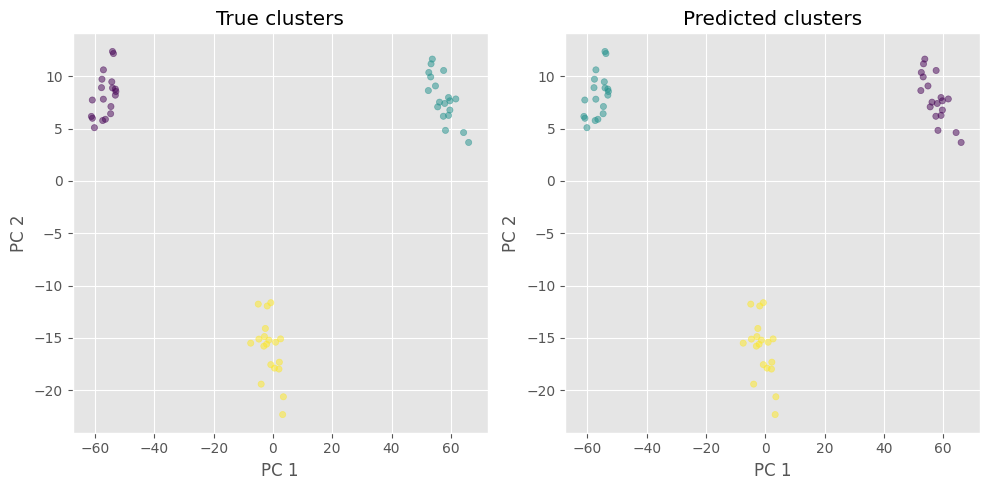

In [33]:
with plt.style.context("ggplot"):
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
    ax[0].scatter(feat_mat_pca[:, 0], feat_mat_pca[:, 1], c=classes_gt, alpha=0.5, s=20)
    ax[0].set_title("True clusters")
    ax[1].scatter(
        feat_mat_pca[:, 0], feat_mat_pca[:, 1], c=clust_labels_pred, alpha=0.5, s=20
    )
    ax[1].set_title("Predicted clusters")
    for axi in ax:
        axi.set_xlabel("PC 1")
        axi.set_ylabel("PC 2")
    fig.tight_layout()
    plt.show()

### New data

In [34]:
# new_data = np.random.normal(6, 1, 70)
# new_feat = np.array([np.mean(new_data), np.std(new_data)])[np.newaxis, :]
# new_feat

In [35]:
new_data = rng.multivariate_normal(
    mean=np.array([6, 1]), cov=covs, size=(seq_length * 2)
)
new_data.shape

(200, 2)

In [36]:
# new_data_scaled = np.squeeze(scaler.transform(new_data))
# new_data_scaled.shape

In [37]:
new_windows = sliding_window(series=new_data, window_size=window_size, step=window_step)
new_windows.shape

(39, 10, 2)

In [38]:
new_feat_mat = pd.DataFrame(extract_features(new_windows))
new_feat_mat

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,350.869094,11.245800,48.770157,1.977518,-0.247033,0.763335,104.321708,4.258651,3.929054,-1.488102,...,0.0,0.0,0.0,1.0,4.255085,0.426743,0.234228,-0.385748,0.0,0.704519
1,345.855466,10.382374,49.084081,1.968180,-0.223022,0.763555,102.023496,3.754043,4.696076,-0.962255,...,0.0,0.0,0.0,1.0,4.220414,0.309321,0.432275,-0.595781,0.0,0.720822
2,360.845478,10.238854,50.725705,1.962224,-0.247033,0.633126,108.631972,5.200109,5.938096,1.407741,...,0.0,0.0,0.0,1.0,4.307461,0.581356,0.988295,0.457749,0.0,0.737022
3,368.572489,10.306690,51.114405,1.969099,-0.261722,0.572005,111.974680,5.417642,4.503167,0.187794,...,0.0,0.0,0.0,1.0,4.352466,0.499652,0.378031,0.677144,0.0,0.733888
4,379.746503,9.001402,52.246884,1.974790,-0.253680,0.446303,117.129927,4.839035,4.168052,-0.894468,...,0.0,0.0,0.0,1.0,4.408786,0.396163,-0.385452,-1.036038,0.0,0.741325
5,359.978000,7.934291,51.381753,1.960605,-0.247033,0.310256,107.756525,3.696580,4.745619,-1.442232,...,0.0,0.0,0.0,1.0,4.289011,0.440556,0.252021,-1.220881,0.0,0.756501
6,357.277475,8.361197,50.976603,1.957725,-0.247033,0.576718,106.499660,3.531819,5.490103,0.309423,...,0.0,0.0,0.0,1.0,4.275738,0.476924,0.650207,-1.132935,0.0,0.750967
7,380.022905,10.581232,51.523313,1.986362,-0.253680,0.567681,117.546248,4.732255,5.283799,0.378344,...,0.0,0.0,0.0,1.0,4.419299,0.348307,0.389857,0.209466,0.0,0.721761
8,358.072943,8.683072,50.824602,1.975107,-0.261722,-0.030102,107.418382,3.611073,4.273589,0.174391,...,0.0,0.0,0.0,1.0,4.282266,0.485508,-0.743820,0.101626,0.0,0.744254
9,351.482329,8.121733,50.486424,1.977094,-0.247033,-0.026755,104.436632,4.693184,3.955221,-0.620429,...,0.0,0.0,0.0,1.0,4.240307,0.371564,-0.240121,-0.851748,0.0,0.747344


In [39]:
# new_feat_scaled = scaler.fit_transform(new_feat)
# new_feat_scaled = pd.DataFrame(new_feat_scaled)
# new_feat_scaled

In [40]:
# gmm.predict(new_feat_mat)

In [41]:
# np.round(gmm.predict_proba(new_feat_mat))

In [42]:
gamma_resp, labels_pred = predict(
    X=new_feat_mat.to_numpy(),
    pi_mixing_prior=pi_mixing_prior,
    mu=mu,
    Sigma=Sigma,
    seed=seed,
)
gamma_resp, labels_pred

(array([[1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.]]),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]))

In [43]:
# from tslearn.preprocessing import TimeSeriesScalerMeanVariance
# from tslearn.clustering import TimeSeriesKMeans
# from tslearn.utils import to_time_series_dataset

# np.random.seed(0)
# time = np.linspace(0, 10, 50)
# series = [np.sin(time + shift) for shift in np.linspace(0, 3, 10)]
# dataset = to_time_series_dataset(series)

# scaler = TimeSeriesScalerMeanVariance()
# dataset_scaled = scaler.fit_transform(dataset)

# model = TimeSeriesKMeans(n_clusters=3, metric="dtw", random_state=0)
# labels = model.fit_predict(dataset_scaled)

# print("Cluster Labels (Shape-Based):", labels)

## Lasa

In [44]:
resample_num = 2**10
print(f"Resampling to {resample_num} data points")
smoothing_factor = 0

Resampling to 1024 data points


In [45]:
def smooth_arr(arr, nb_points=256, smoothing_factor=0):
    index_ori = np.arange(start=0, stop=arr.shape[0])
    new_index = np.linspace(start=0, stop=arr.shape[0], num=nb_points)
    arr_smooth = make_splrep(x=index_ori, y=arr, s=smoothing_factor)(new_index)
    return arr_smooth

In [46]:
datasets = [lasa.DataSet.heee, lasa.DataSet.Line, lasa.DataSet.Saeghe]
X = None
classes_gt = None
for idx, data in enumerate(datasets):
    # dt = data.dt
    demos = data.demos
    demo_id = 0
    demo = demos[demo_id]
    pos = demo.pos.T
    pos_resampled = smooth_arr(
        arr=pos, nb_points=resample_num, smoothing_factor=smoothing_factor
    )
    # pos_resampled = pos
    if X is None:
        X = np.hstack((np.arange(pos_resampled.shape[0])[:, np.newaxis], pos_resampled))
        classes_gt = np.ones((pos_resampled.shape[0],), dtype=int) * idx
    else:
        # dist_from_last_point = np.abs(X[-1, :] - pos_resampled[0, :])
        pos_with_time = np.hstack(
            (np.arange(pos_resampled.shape[0])[:, np.newaxis], pos_resampled)
        )
        # X = np.vstack((X, pos_resampled - dist_from_last_point))
        X = np.vstack((X, pos_with_time))
        classes_gt = np.hstack(
            (classes_gt, np.ones(pos_resampled.shape[0], dtype=int) * idx)
        )
# X = np.hstack((np.arange(X.shape[0])[:, np.newaxis], X))
print(X.shape)
print(classes_gt.shape)
dataset = pd.DataFrame(
    {
        "t": X[:, 0],
        "pos_x": X[:, 1],
        "pos_y": X[:, 2],
        "y_cls": classes_gt,
    }
)
dataset

(3072, 3)
(3072,)


,t,pos_x,pos_y,y_cls
0,0.0,-31.414643,18.078238,0
1,1.0,-31.414425,18.078527,0
2,2.0,-31.413891,18.079220,0
3,3.0,-31.413022,18.080319,0
4,4.0,-31.411800,18.081830,0
...,...,...,...,...
3067,1019.0,0.001816,0.001816,2
3068,1020.0,0.000857,0.000857,2
3069,1021.0,0.000250,0.000250,2
3070,1022.0,-0.000002,-0.000002,2


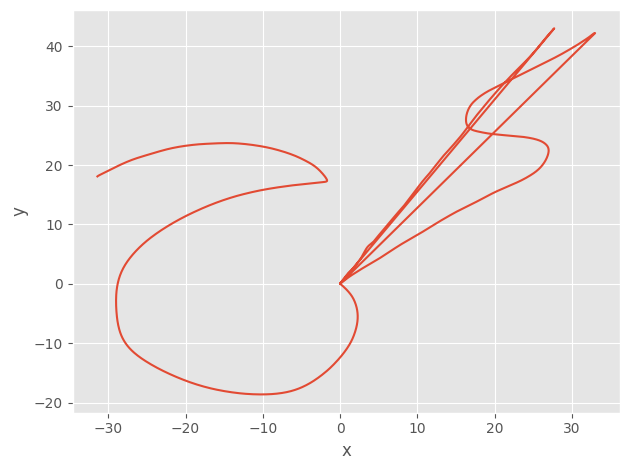

In [47]:
with plt.style.context("ggplot"):
    fig, ax = plt.subplots()
    ax.plot(dataset.pos_x, dataset.pos_y)  # , c=blobs[1], alpha=0.5, s=20)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.tight_layout()
    plt.show()

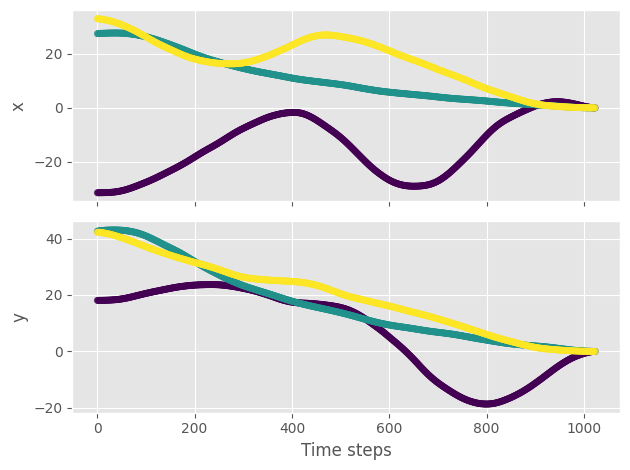

In [48]:
with plt.style.context("ggplot"):
    fig, ax = plt.subplots(2, 1, sharex=True)
    ax[0].scatter(dataset.t, dataset.pos_x, c=dataset.y_cls, alpha=0.5, s=20)
    ax[1].scatter(dataset.t, dataset.pos_y, c=dataset.y_cls, alpha=0.5, s=20)
    ax[0].set_ylabel("x")
    ax[1].set_ylabel("y")
    ax[1].set_xlabel("Time steps")
    fig.tight_layout()
    plt.show()

In [49]:
dataset[["pos_x", "pos_y"]]

,pos_x,pos_y
0,-31.414643,18.078238
1,-31.414425,18.078527
2,-31.413891,18.079220
3,-31.413022,18.080319
4,-31.411800,18.081830
...,...,...
3067,0.001816,0.001816
3068,0.000857,0.000857
3069,0.000250,0.000250
3070,-0.000002,-0.000002


In [50]:
# scaler = TimeSeriesScalerMeanVariance()
# ds_scaled = np.squeeze(scaler.fit_transform(dataset[["pos_x", "pos_y"]]))
# ds_scaled.shape

In [51]:
windows = sliding_window(
    series=dataset[["pos_x", "pos_y"]], window_size=window_size, step=window_step
)
windows.shape

(613, 10, 2)

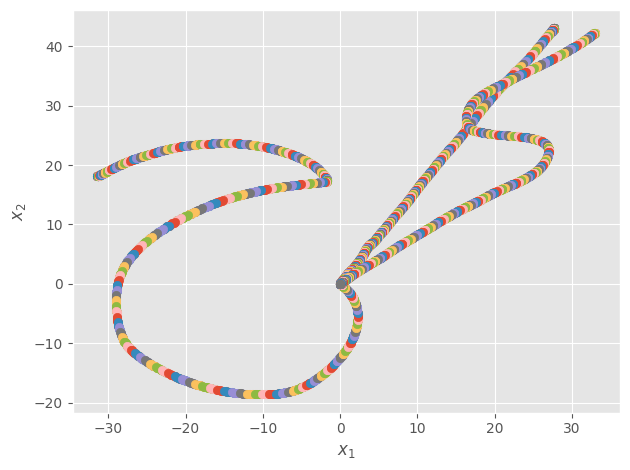

In [52]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots()
    for idx in range(windows.shape[0]):
        ax.scatter(windows[idx, :, 0], windows[idx, :, 1])  # , color=cmap[idx])
    ax.set_xlabel(f"$x_1$")
    ax.set_ylabel(f"$x_2$")
    fig.tight_layout()
    plt.show()

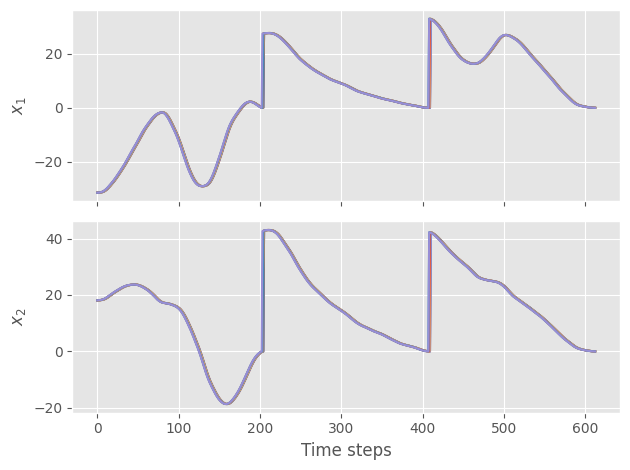

In [53]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots(windows.shape[-1], 1, sharex=True)
    for idx in range(windows.shape[-1]):
        for jdx in range(windows.shape[1]):
            ax[idx].plot(windows[:, jdx, idx])  # , c=cmap[jdx])
        ax[idx].set_ylabel(f"$x_{idx + 1}$")
    ax[idx].set_xlabel("Time steps")
    fig.tight_layout()
    plt.show()

In [54]:
feat_mat = extract_features(windows)
feat_mat.shape

(613, 33)

In [55]:
for col in range(feat_mat.shape[1]):
    if np.any(np.isnan(feat_mat[:, col])):
        feat_mat = np.delete(arr=feat_mat, obj=col, axis=1)
feat_mat = pd.DataFrame(feat_mat)
feat_mat

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,9865.556148,3270.477519,4.949394e+02,2.000000,0.062915,0.864123,-1.253636e+04,1.177736,1.154765,-0.436071,...,0.0,0.0,0.0,1.0,25.628142,0.242946,0.845209,0.781824,0.0,-3.714361
1,9857.342780,3275.774166,4.949550e+02,1.999999,0.062915,0.864123,-1.250983e+04,1.036605,1.032189,-1.273317,...,0.0,0.0,0.0,1.0,25.625297,0.242946,0.331213,0.282454,0.0,-3.722220
2,9844.628938,3283.517991,4.949662e+02,1.999999,0.062915,0.864123,-1.246938e+04,1.077593,1.068219,-1.013503,...,0.0,0.0,0.0,1.0,25.620448,0.242946,0.167125,0.105261,0.0,-3.733996
3,9827.260625,3293.153586,4.949550e+02,1.999998,0.062915,0.864123,-1.241542e+04,1.071804,1.056974,-1.043718,...,0.0,0.0,0.0,1.0,25.612901,0.242946,0.349061,0.235896,0.0,-3.749258
4,9801.228901,3305.906182,4.948904e+02,1.999997,0.062915,0.864123,-1.233687e+04,1.064599,1.055930,-1.084973,...,0.0,0.0,0.0,1.0,25.599937,0.242946,0.312708,0.227945,0.0,-3.770663
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
608,0.073421,0.073421,6.643991e-14,-1.032588,-0.094032,-0.094032,5.983441e-04,1.045884,1.045884,-1.191771,...,0.0,0.0,0.0,1.0,0.085686,0.117783,0.107998,0.107998,0.0,0.182068
609,0.037145,0.037145,7.201878e-14,-1.033487,-0.544187,-0.544187,2.103639e-04,1.047095,1.047095,-1.184862,...,0.0,0.0,0.0,1.0,0.060947,0.117783,0.139445,0.139445,0.0,0.220884
610,0.016108,0.016108,8.124751e-14,-1.001447,0.160269,0.160269,5.753194e-05,1.065637,1.065637,-1.103618,...,0.0,0.0,0.0,1.0,0.040135,0.117783,0.120446,0.120446,0.0,0.283233
611,0.005192,0.005192,6.583189e-14,-1.121654,0.815904,0.815904,8.517755e-06,1.026773,1.026773,-1.345637,...,0.0,0.0,0.0,1.0,0.022785,0.117783,0.156285,0.156285,0.0,0.468211


In [56]:
y_cls_win = np.round(
    np.mean(
        sliding_window(series=dataset.y_cls, window_size=window_size, step=window_step),
        axis=1,
        dtype=int,
    )
)

In [57]:
# scaler = StandardScaler()
# feat_scaled = scaler.fit_transform(features)
# feat_scaled = pd.DataFrame(feat_scaled)
# # feat_scaled = features
# feat_scaled

In [58]:
pca = PCA(n_components=2)
feat_mat_pca = pca.fit_transform(feat_mat)
feat_mat_pca.shape

(613, 2)

In [59]:
# gmm = GaussianMixture(n_components=K_components, random_state=seed)
# gmm.fit(feat_mat)
# clust_labels_pred = gmm.predict(feat_mat)
# proba = gmm.predict_proba(feat_mat)
# clust_labels_pred  #, np.round(proba)

Converged at iteration 47


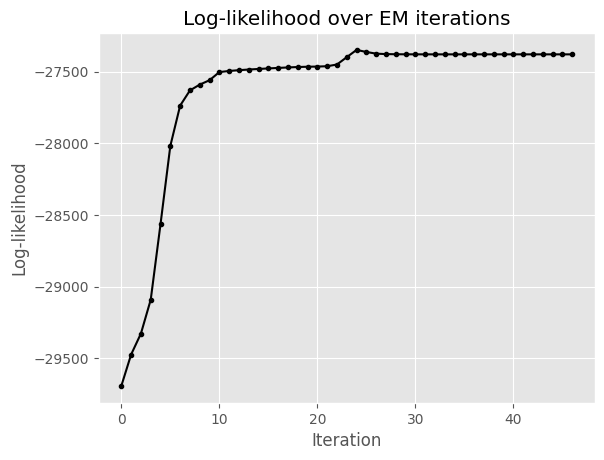

(array([[ 5.39673962e+03,  1.01424838e+04,  1.00394159e+02,
          1.92931373e+00,  4.86614567e-01,  1.94283679e-01,
          2.38905631e+04,  1.07836139e+00,  1.06346284e+00,
         -1.10856899e+00, -1.16776340e+00,  9.60520711e-01,
          9.72367481e-01,  5.02255648e+00,  5.04497034e+00,
          4.97180418e+00,  4.95493693e+00,  1.00394159e+01,
          1.24712048e-02,  1.71139983e-03, -5.23787166e-05,
         -6.41716694e-05,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  1.00000000e+00,
          2.73222458e+01,  2.39794921e-01, -3.82770513e-02,
         -5.26811018e-02,  0.00000000e+00,  1.90945885e-01],
        [ 4.04973892e+02,  4.75950984e+02,  3.44718223e+01,
         -4.18641290e-01,  3.96637935e-01,  3.42558213e-01,
         -6.63079961e-01,  1.17300392e+00,  1.14663776e+00,
         -7.96567847e-01, -8.16800575e-01,  9.35170648e-01,
          9.48286163e-01,  4.79205291e+00,  4.79132186e+00,
          5.15577755e+00,  5.20867814e+

In [60]:
reg_coef = 1e-1
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior = run_EM(
    X=feat_mat.to_numpy(), K_components=K_components, reg_coef=reg_coef, seed=seed
)
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior

In [61]:
# np.round(gmm.means_), np.round(gmm.covariances_)

In [62]:
y_cls_win, clust_labels_pred

(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

In [63]:
print(f"Silhouette: {metrics.silhouette_score(X=feat_mat, labels=clust_labels_pred)}")
print(
    f"Completeness: {metrics.completeness_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Fowlkes-Mallows index: {metrics.fowlkes_mallows_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Homogeneity: {metrics.homogeneity_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Mutual Information: {metrics.mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted mutual information: {metrics.adjusted_mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Normalized Mutual Information: {metrics.normalized_mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Rand index: {metrics.rand_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted rand index: {metrics.adjusted_rand_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"V-measure: {metrics.v_measure_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)

Silhouette: -0.12312566410067752
Completeness: 0.2291992002037639
Fowlkes-Mallows index: 0.5059037877526568
Homogeneity: 0.16929952289368325
Mutual Information: 0.18599273218114792
Adjusted mutual information: 0.19195523240220397
Normalized Mutual Information: 0.19474750102334568
Rand index: 0.5754566100502191
Adjusted rand index: 0.1554238412621935
V-measure: 0.19474750102334568


In [64]:
uncertainty = 1 - gamma_resp.max(axis=1)

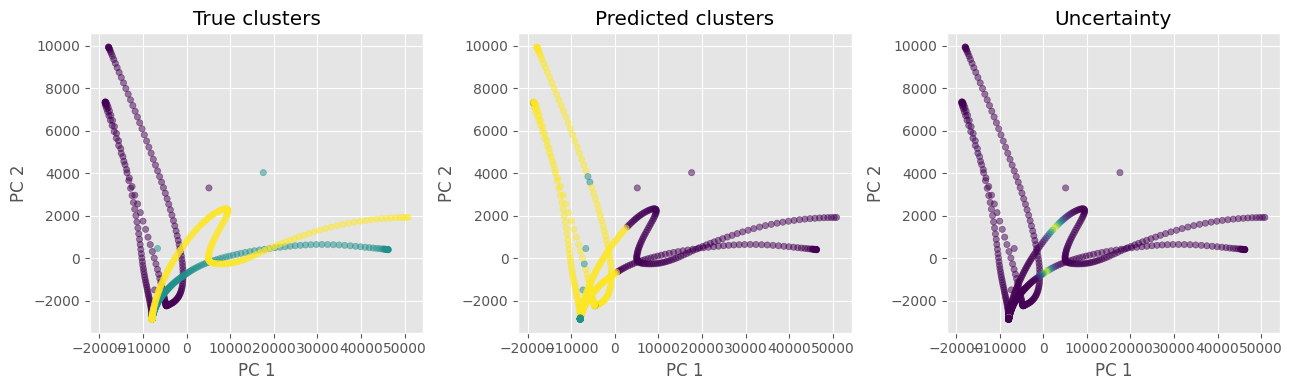

In [65]:
with plt.style.context("ggplot"):
    fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(13, 4))
    ax[0].scatter(feat_mat_pca[:, 0], feat_mat_pca[:, 1], c=y_cls_win, alpha=0.5, s=20)
    ax[0].set_title("True clusters")
    ax[1].scatter(
        feat_mat_pca[:, 0], feat_mat_pca[:, 1], c=clust_labels_pred, alpha=0.5, s=20
    )
    ax[1].set_title("Predicted clusters")
    ax[2].scatter(
        feat_mat_pca[:, 0], feat_mat_pca[:, 1], c=uncertainty, alpha=0.5, s=20
    )
    ax[2].set_title("Uncertainty")
    for axi in ax:
        axi.set_xlabel("PC 1")
        axi.set_ylabel("PC 2")
    fig.tight_layout()
    plt.show()

## Synthetic hierarchical (toy) data

In [66]:
# def plot_gaussian_hmm(
#     hmm, params, emissions, states, title="Emission Distributions", alpha=0.25
# ):
#     lim = 1.1 * abs(emissions).max()
#     XX, YY = jnp.meshgrid(jnp.linspace(-lim, lim, 100), jnp.linspace(-lim, lim, 100))
#     grid = jnp.column_stack((XX.ravel(), YY.ravel()))

#     plt.figure()
#     for k in range(hmm.num_states):
#         lls = hmm.emission_distribution(params, k).log_prob(grid)
#         plt.contour(
#             XX, YY, jnp.exp(lls).reshape(XX.shape), cmap=white_to_color_cmap(COLORS[k])
#         )
#         plt.plot(
#             emissions[states == k, 0],
#             emissions[states == k, 1],
#             "o",
#             mfc=COLORS[k],
#             mec="none",
#             ms=3,
#             alpha=alpha,
#         )

#     plt.plot(emissions[:, 0], emissions[:, 1], "-k", lw=1, alpha=alpha)
#     plt.xlabel("$y_1$")
#     plt.ylabel("$y_2$")
#     plt.title(title)
#     plt.gca().set_aspect(1.0)
#     plt.tight_layout()

In [67]:
def generate_two_level_hmm_sequence(
    seq_length,
    n_meta,
    n_sub,
    obs_dim,
    A_meta,
    A_sub,
    pi_meta,
    pi_sub,
    means,
    covariances,
    seed=None,
):
    """
    Generate sequence from a 2-level HMM.

    Parameters:
    - A_meta: (n_meta, n_meta) meta-state transition matrix
    - A_sub: (n_meta, n_sub, n_sub) sub-state transition (depends on meta)
    - pi_meta: (n_meta,) initial meta distribution
    - pi_sub: (n_meta, n_sub) initial sub distribution given meta
    - means: (n_meta, n_sub) observation means
    - covariances: (n_meta, n_sub, obs_dim, obs_dim) covariance matrices
    """
    rng = np.random.default_rng(seed)

    # Initialize arrays
    meta_states = np.zeros(seq_length, dtype=int)
    sub_states = np.zeros(seq_length, dtype=int)
    observations = np.zeros((seq_length, obs_dim))

    # Sample initial states
    meta_states[0] = rng.choice(n_meta, p=pi_meta)
    sub_states[0] = rng.choice(n_sub, p=pi_sub[meta_states[0]])

    # Generate first observation (multi-dimensional)
    observations[0] = rng.multivariate_normal(
        mean=means[meta_states[0], sub_states[0]],
        cov=covariances[meta_states[0], sub_states[0]],
    )

    # Generate rest of the sequence
    for t in range(1, seq_length):
        # Meta-state transition (depends only on previous meta)
        meta_states[t] = rng.choice(n_meta, p=A_meta[meta_states[t - 1]])

        # Check if meta-state changed
        if meta_states[t] != meta_states[t - 1]:
            # RESET: Sample sub-state from initial distribution
            sub_states[t] = rng.choice(n_sub, p=pi_sub[meta_states[t]])
        else:
            # Normal transition within same meta-state
            sub_states[t] = rng.choice(
                n_sub, p=A_sub[meta_states[t], sub_states[t - 1]]
            )

        # Multi-dimensional observation (depends on current meta and sub)
        observations[t] = rng.multivariate_normal(
            mean=means[meta_states[t], sub_states[t]],
            cov=covariances[meta_states[t], sub_states[t]],
            # size=(obs_dim),
        )

    return meta_states, sub_states, observations

In [68]:
n_meta = 3
n_sub = 4
obs_dim = 2

# Transition matrices
A_meta = np.array(
    [
        [0.8, 0.1, 0.1],  # from meta 0
        [0.1, 0.8, 0.1],  # from meta 1
        [0.1, 0.1, 0.8],  # from meta 2
    ]
)

# Sub-state transitions for each meta-state
A_sub = np.zeros((n_meta, n_sub, n_sub))
# Meta 0: tends to stay in same sub-state
A_sub[0] = np.array(
    [
        [0.7, 0.1, 0.1, 0.1],
        [0.1, 0.7, 0.1, 0.1],
        [0.1, 0.1, 0.7, 0.1],
        [0.1, 0.1, 0.1, 0.7],
    ]
)
# Meta 1: tends to increase sub-state
A_sub[1] = np.array(
    [
        [0.4, 0.6, 0.0, 0.0],
        [0.0, 0.4, 0.6, 0.0],
        [0.0, 0.0, 0.4, 0.6],
        [0.6, 0.0, 0.0, 0.4],
    ]
)
# Meta 2: tends to decrease sub-state
# A_sub[2] = np.array(
#     [
#         [0.4, 0.0, 0.0, 0.6],
#         [0.6, 0.4, 0.0, 0.0],
#         [0.0, 0.6, 0.4, 0.0],
#         [0.0, 0.0, 0.6, 0.4],
#     ]
# )
# Meta 2: tends to increase sub-state
A_sub[2] = np.array(
    [
        [0.4, 0.6, 0.0, 0.0],
        [0.0, 0.4, 0.6, 0.0],
        [0.0, 0.0, 0.4, 0.6],
        [0.6, 0.0, 0.0, 0.4],
    ]
)

# Initial distributions
pi_meta = np.array([0.34, 0.33, 0.33])  # uniform-ish
# pi_sub = np.array(
#     [
#         [0.4, 0.3, 0.2, 0.1],  # given meta 0
#         [0.1, 0.2, 0.3, 0.4],  # given meta 1
#         [0.25, 0.25, 0.25, 0.25],  # given meta 2
#     ]
# )
pi_sub = np.array(
    [
        [0.6, 0.1, 0.2, 0.1],  # given meta 0
        [0.2, 0.6, 0.1, 0.1],  # given meta 1
        [0.0, 0.2, 0.6, 0.2],  # given meta 2
    ]
)


# Multi-dimensional observation parameters
means = np.zeros((n_meta, n_sub, obs_dim))
covariances = np.zeros((n_meta, n_sub, obs_dim, obs_dim))

# # Make means distinct for different meta-sub combinations
# for m in range(n_meta):
#     for s in range(n_sub):
#         means[m, s] = m * 10 + s * 2  # e.g., meta0: 0,2,4,6; meta1: 10,12,14,16; etc.

# Define different (meta, sub) pairs to have distinct 2D Gaussian distributions
for m in range(n_meta):
    for s in range(n_sub):
        # Different centers for each state
        means[m, s, :] = [
            m * 10 + s * 2,
            m * 5 + s * 1.5,
            # m * 15 + s * 2.5,
            # m * 20 + s * 1,
            # m * 0 + s * 0,
        ]

        # Different covariance structures
        if m == 0:  # Meta 0: isotropic
            covariances[m, s] = np.eye(obs_dim) * (s + 1)
        elif m == 1:  # Meta 1: correlated
            covariances[m, s] = np.array([[2.0, 0.8], [0.8, 1.0]]) * (s + 1)
        else:  # Meta 2: anti-correlated
            covariances[m, s] = np.array([[2.0, -0.5], [-0.5, 1.0]]) * (s + 1)

In [69]:
# Generate sequence
meta_states, sub_states, observations = generate_two_level_hmm_sequence(
    seq_length=seq_length,
    n_meta=n_meta,
    n_sub=n_sub,
    obs_dim=obs_dim,
    A_meta=A_meta,
    A_sub=A_sub,
    pi_meta=pi_meta,
    pi_sub=pi_sub,
    means=means,
    covariances=covariances,
    seed=seed,
)

print(f"Meta states:  {meta_states}")
print(f"Sub states:   {sub_states}")
print(f"Observations:\n{np.round(observations[:10, :], 2)}\n [...]")

Meta states:  [2 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 1 1 1 0 0 0 0 2 2 0 0 0 0 0 0 0 2 2 2
 2 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 2 2 2 2 2 2 2 1 2 1 0 0 0 0 1 1
 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 1 1 1 1]
Sub states:   [2 3 3 3 0 0 0 0 0 0 2 2 2 3 0 1 2 0 1 2 3 0 0 0 0 2 3 3 3 3 3 3 3 3 2 3 0
 0 1 2 3 0 1 2 3 3 3 0 1 2 3 0 0 2 1 1 3 1 2 3 3 3 0 0 0 2 1 0 0 0 0 0 0 1
 2 3 3 0 0 1 2 3 0 0 1 2 3 0 1 1 2 3 0 1 2 3 2 3 0 1]
Observations:
[[22.77 15.08]
 [ 6.26  3.87]
 [ 7.76  6.06]
 [ 6.94  2.78]
 [ 0.88 -0.05]
 [ 1.22 -0.15]
 [ 0.53  0.37]
 [ 2.14 -0.41]
 [ 0.62  1.13]
 [-0.82  0.65]]
 [...]


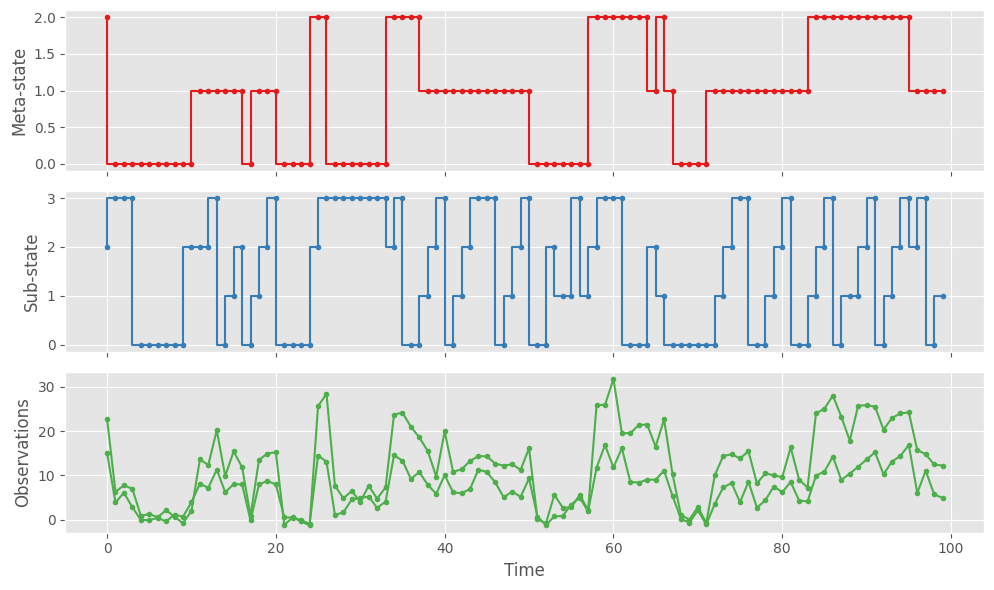

In [70]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["Set1"].colors
    fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 6))
    axes[0].step(meta_states, ".-", c=cmap[0])
    axes[0].set_ylabel("Meta-state")
    axes[1].step(sub_states, ".-", c=cmap[1])
    axes[1].set_ylabel("Sub-state")
    axes[2].plot(observations, ".-", c=cmap[2])
    axes[2].set_ylabel("Observations")
    axes[2].set_xlabel("Time")
    plt.tight_layout()
    plt.show()

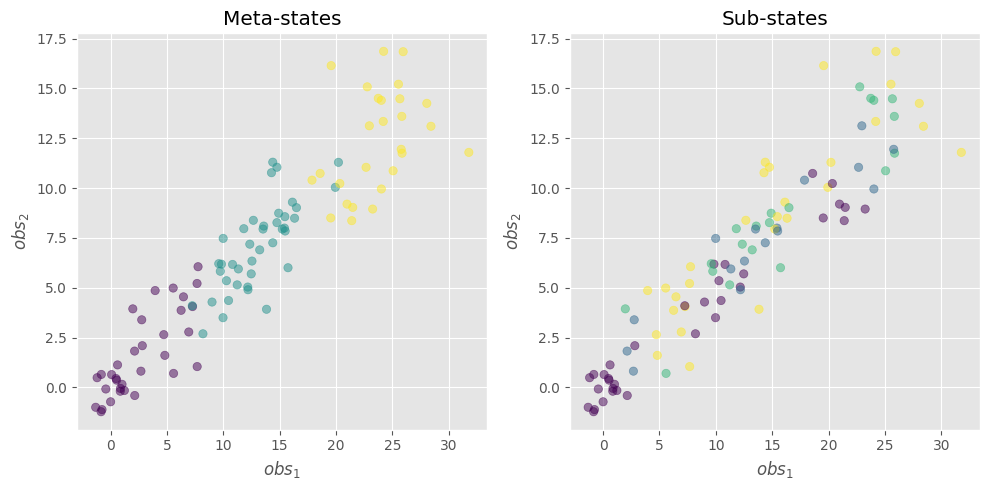

In [71]:
with plt.style.context("ggplot"):
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
    ax[0].scatter(observations[:, 0], observations[:, 1], alpha=0.5, c=meta_states)
    ax[1].scatter(observations[:, 0], observations[:, 1], alpha=0.5, c=sub_states)
    ax[0].set_title("Meta-states")
    ax[1].set_title("Sub-states")
    for axi in ax:
        axi.set_xlabel(f"$obs_1$")
        axi.set_ylabel(f"$obs_2$")
    fig.tight_layout()
    plt.show()

In [72]:
windows = sliding_window(series=observations, window_size=window_size, step=window_step)
windows.shape

(19, 10, 2)

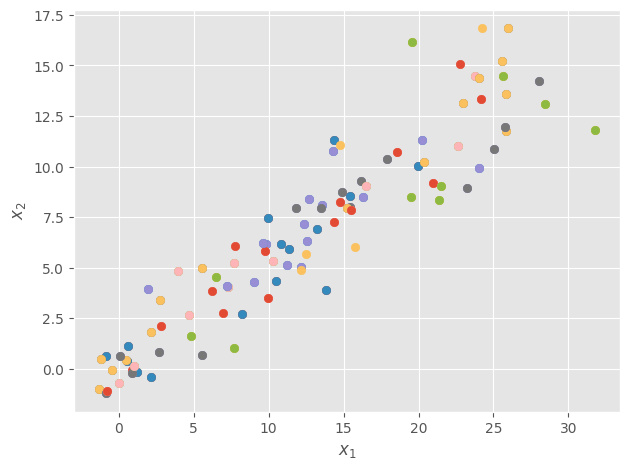

In [73]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots()
    for idx in range(windows.shape[0]):
        ax.scatter(windows[idx, :, 0], windows[idx, :, 1])  # , color=cmap[idx])
    ax.set_xlabel(f"$x_1$")
    ax.set_ylabel(f"$x_2$")
    fig.tight_layout()
    plt.show()

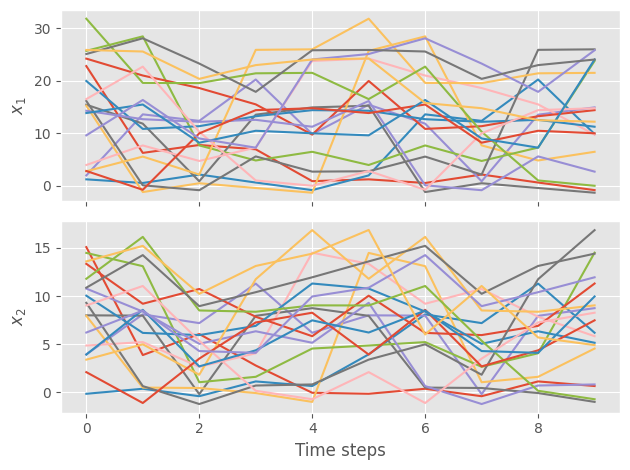

In [74]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots(windows.shape[-1], 1, sharex=True)
    for idx in range(windows.shape[-1]):
        for jdx in range(windows.shape[0]):
            ax[idx].plot(windows[jdx, :, idx])  # , c=cmap[jdx])
        ax[idx].set_ylabel(f"$x_{idx + 1}$")
    ax[idx].set_xlabel("Time steps")
    fig.tight_layout()
    plt.show()

In [75]:
feat_mat = extract_features(windows)
feat_mat.shape

(19, 33)

In [76]:
for col in range(feat_mat.shape[1]):
    if np.any(np.isnan(feat_mat[:, col])):
        feat_mat = np.delete(arr=feat_mat, obj=col, axis=1)
feat_mat = pd.DataFrame(feat_mat)
feat_mat

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,674.144034,288.768962,22.945302,-0.601404,-0.025294,0.709353,42.842151,2.693654,2.743809,5.285951,...,0.0,0.0,0.0,1.0,6.938707,0.446287,2.166848,2.201973,0.0,1.482468
1,853.839443,300.424034,31.282725,-1.178621,0.822350,0.549349,43.408929,2.604282,2.211922,-0.467444,...,0.0,0.0,0.0,1.0,7.596919,0.530628,0.915748,0.612723,0.0,1.145392
2,1630.035048,565.258161,49.290146,0.132442,0.851382,0.019019,1076.773478,4.453304,4.761859,0.349244,...,0.0,0.0,0.0,1.0,10.476863,0.485508,-0.820156,-1.338630,0.0,0.549449
3,1019.156018,331.397361,33.759455,-0.247165,0.812934,-0.215303,384.065958,3.252008,3.355127,-2.422024,...,0.0,0.0,0.0,1.0,8.217522,0.650588,0.032248,-0.020620,0.0,1.118212
4,1826.075525,470.124963,47.942084,0.149716,0.668929,0.538402,884.372505,3.649669,3.957539,-0.289541,...,0.0,0.0,0.0,1.0,10.714944,0.650588,1.027928,1.086228,0.0,1.336376
5,2304.169454,690.160171,56.166921,-0.353947,-0.027669,0.808305,1014.942440,2.974158,3.286041,-1.012001,...,0.0,0.0,0.0,1.0,12.235869,0.446287,1.018671,0.799777,0.0,0.849958
6,2418.761679,757.940128,59.920899,-0.939121,0.579576,0.610064,1199.655629,2.533712,3.217631,-1.823841,...,0.0,0.0,0.0,1.0,12.602979,0.318454,0.167035,0.530991,0.0,0.616523
7,2730.181259,822.758013,71.384083,0.959869,0.913132,0.543653,2552.715490,3.440581,3.741429,-1.065433,...,0.0,0.0,0.0,1.0,13.328427,0.318454,0.390737,0.443056,0.0,0.417675
8,1820.769149,627.684594,56.570814,1.331675,0.864123,0.293855,1473.910622,3.851464,3.341936,4.920046,...,0.0,0.0,0.0,1.0,11.064479,0.318454,2.027723,0.594192,0.0,0.353886
9,1095.135571,367.734194,41.736884,-0.062157,0.835828,-0.017554,534.080876,3.118177,2.756541,-1.437481,...,0.0,0.0,0.0,1.0,8.552397,0.485508,-0.550613,0.057259,0.0,0.817166


In [77]:
pca = PCA(n_components=2)
feat_mat_pca = pca.fit_transform(feat_mat)
feat_mat_pca.shape

(19, 2)

### Meta-states clustering

In [78]:
y_cls_win = np.round(
    np.mean(
        sliding_window(series=meta_states, window_size=window_size, step=window_step),
        axis=1,
        dtype=int,
    )
)
y_cls_win

array([0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 2, 1])

In [79]:
# gmm = GaussianMixture(n_components=n_meta, random_state=seed)
# gmm.fit(feat_mat)
# clust_labels_pred = gmm.predict(feat_mat)
# proba = gmm.predict_proba(feat_mat)
# clust_labels_pred  #, np.round(proba)

Converged at iteration 2


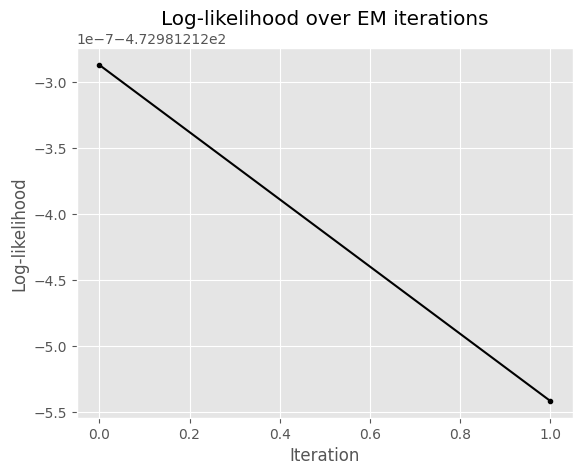

(array([[ 3.71966268e+03,  1.01192816e+03,  8.50683569e+01,
          3.78048503e-01,  7.40581213e-01,  6.24250344e-01,
          3.47276104e+03,  2.72296519e+00,  3.26032514e+00,
         -1.13741524e+00, -7.47726430e-01,  7.60000088e-01,
          8.00000000e-01,  5.39999913e+00,  4.60000089e+00,
          3.60000088e+00,  3.40000132e+00,  8.50683569e+00,
         -4.51717836e-01, -2.63897244e-01,  1.75805273e-01,
         -9.44886222e-03,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  1.00000000e+00,
          1.53369691e+01,  4.36088199e-01, -3.05861481e-01,
         -9.37018483e-02,  0.00000000e+00,  5.47641796e-01],
        [ 1.52057189e+03,  4.65151898e+02,  4.62939634e+01,
         -2.12712289e-01,  6.02781055e-01,  3.38085841e-01,
          6.91939952e+02,  3.24000253e+00,  3.35897827e+00,
          2.97445670e-01, -3.18959342e-01,  7.07692230e-01,
          7.61538429e-01,  3.30769088e+00,  3.23076773e+00,
          4.38461571e+00,  4.15384628e+

In [80]:
reg_coef = 1e-3
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior = run_EM(
    X=feat_mat.to_numpy(), K_components=n_meta, reg_coef=reg_coef, seed=seed
)
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior

In [81]:
# np.round(gmm.means_), np.round(gmm.covariances_)

In [82]:
y_cls_win, clust_labels_pred

(array([0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 2, 1]),
 array([1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 2, 0]))

In [83]:
print(f"Silhouette: {metrics.silhouette_score(X=feat_mat, labels=clust_labels_pred)}")
print(
    f"Completeness: {metrics.completeness_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Fowlkes-Mallows index: {metrics.fowlkes_mallows_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Homogeneity: {metrics.homogeneity_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Mutual Information: {metrics.mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted mutual information: {metrics.adjusted_mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Normalized Mutual Information: {metrics.normalized_mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Rand index: {metrics.rand_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted rand index: {metrics.adjusted_rand_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"V-measure: {metrics.v_measure_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)

Silhouette: 0.6513489801485185
Completeness: 0.6363241102377675
Fowlkes-Mallows index: 0.723644436333627
Homogeneity: 0.5687114014930293
Mutual Information: 0.4873843941962124
Adjusted mutual information: 0.5371802375464232
Normalized Mutual Information: 0.6006209327679468
Rand index: 0.7368421052631579
Adjusted rand index: 0.47592453858203365
V-measure: 0.6006209327679467


In [84]:
uncertainty = 1 - gamma_resp.max(axis=1)

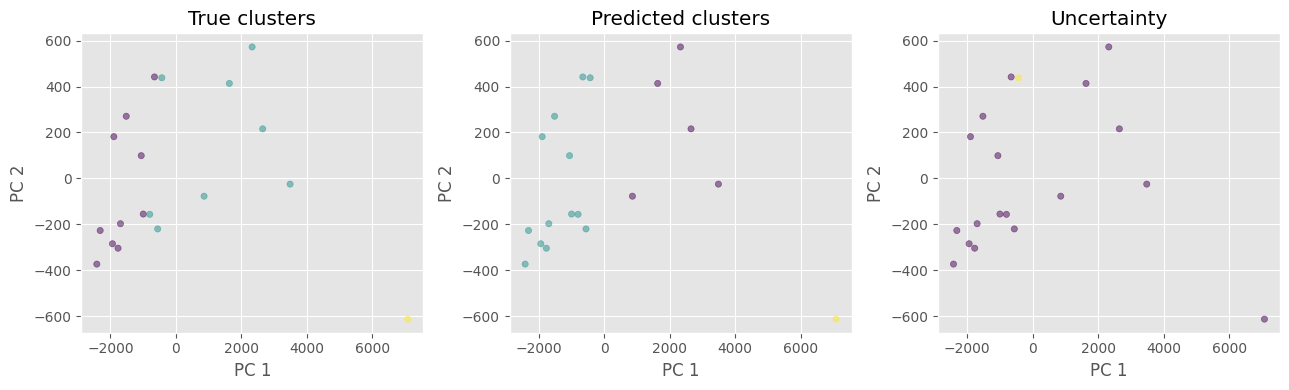

In [85]:
with plt.style.context("ggplot"):
    fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(13, 4))
    ax[0].scatter(feat_mat_pca[:, 0], feat_mat_pca[:, 1], c=y_cls_win, alpha=0.5, s=20)
    ax[0].set_title("True clusters")
    ax[1].scatter(
        feat_mat_pca[:, 0], feat_mat_pca[:, 1], c=clust_labels_pred, alpha=0.5, s=20
    )
    ax[1].set_title("Predicted clusters")
    ax[2].scatter(
        feat_mat_pca[:, 0], feat_mat_pca[:, 1], c=uncertainty, alpha=0.5, s=20
    )
    ax[2].set_title("Uncertainty")
    for axi in ax:
        axi.set_xlabel("PC 1")
        axi.set_ylabel("PC 2")
    fig.tight_layout()
    plt.show()

### Sub-states clustering

In [86]:
y_cls_win = np.round(
    np.mean(
        sliding_window(series=sub_states, window_size=window_size, step=window_step),
        axis=1,
        dtype=int,
    )
)
y_cls_win

array([1, 0, 1, 0, 1, 2, 2, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1])

In [87]:
# gmm = GaussianMixture(n_components=n_sub, random_state=seed)
# gmm.fit(feat_mat)
# clust_labels_pred = gmm.predict(feat_mat)
# proba = gmm.predict_proba(feat_mat)
# clust_labels_pred  #, np.round(proba)

In [88]:
# np.round(gmm.means_), np.round(gmm.covariances_)

Converged at iteration 2


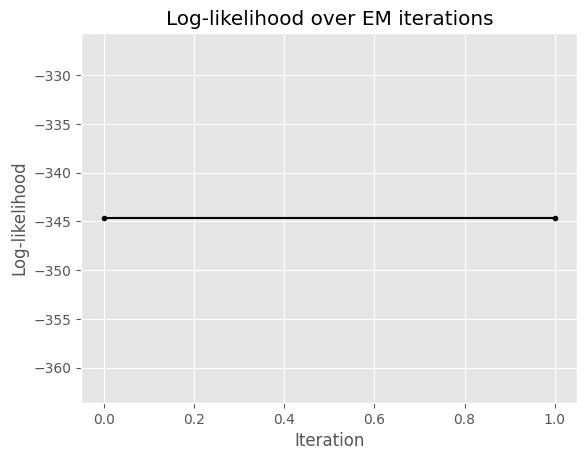

(array([[ 2.73018126e+03,  8.22758013e+02,  7.13840826e+01,
          9.59868754e-01,  9.13132207e-01,  5.43652841e-01,
          2.55271549e+03,  3.44058143e+00,  3.74142855e+00,
         -1.06543328e+00, -9.72637013e-01,  8.00000000e-01,
          9.00000000e-01,  3.00000000e+00,  3.00000000e+00,
          4.00000000e+00,  3.00000000e+00,  7.13840826e+00,
         -1.08912718e+00, -2.27092295e-01,  2.73183508e-01,
          5.34120102e-01,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  1.00000000e+00,
          1.33284269e+01,  3.18453731e-01,  3.90737262e-01,
          4.43055704e-01,  0.00000000e+00,  4.17675381e-01],
        [ 1.52057265e+03,  4.65152145e+02,  4.62939749e+01,
         -2.12712905e-01,  6.02781035e-01,  3.38086071e-01,
          6.91940378e+02,  3.24000193e+00,  3.35897815e+00,
          2.97443880e-01, -3.18959898e-01,  7.07692308e-01,
          7.61538462e-01,  3.30769231e+00,  3.23076923e+00,
          4.38461538e+00,  4.15384615e+

In [89]:
reg_coef = 1e-3
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior = run_EM(
    X=feat_mat.to_numpy(), K_components=n_sub, reg_coef=reg_coef, seed=seed
)
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior

In [90]:
print(f"Silhouette: {metrics.silhouette_score(X=feat_mat, labels=clust_labels_pred)}")
print(
    f"Completeness: {metrics.completeness_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Fowlkes-Mallows index: {metrics.fowlkes_mallows_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Homogeneity: {metrics.homogeneity_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Mutual Information: {metrics.mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted mutual information: {metrics.adjusted_mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Normalized Mutual Information: {metrics.normalized_mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Rand index: {metrics.rand_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted rand index: {metrics.adjusted_rand_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"V-measure: {metrics.v_measure_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)

Silhouette: 0.4417998516260908
Completeness: 0.08164896276487495
Fowlkes-Mallows index: 0.41420843478975694
Homogeneity: 0.08887296637270246
Mutual Information: 0.07328992035003307
Adjusted mutual information: -0.12287094380653867
Normalized Mutual Information: 0.085107945457435
Rand index: 0.42105263157894735
Adjusted rand index: -0.1580135440180587
V-measure: 0.08510794545743498


In [91]:
uncertainty = 1 - gamma_resp.max(axis=1)

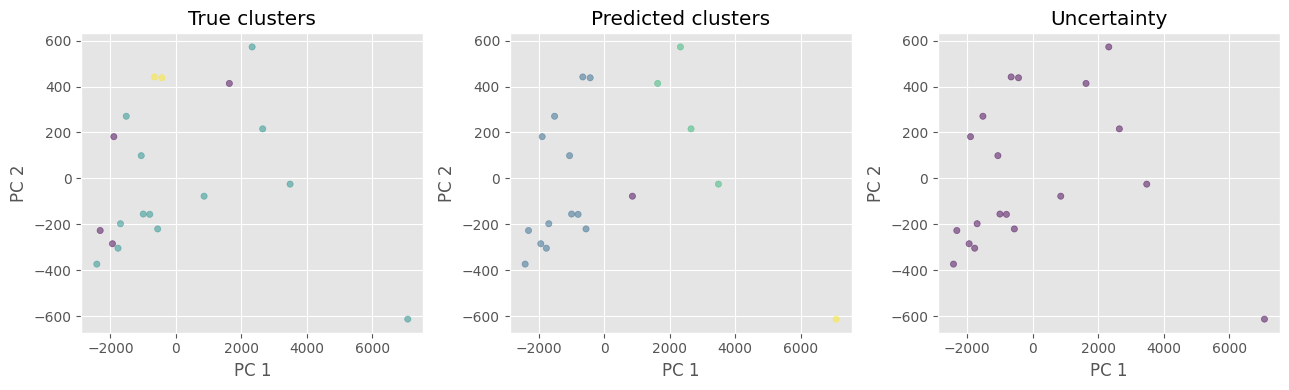

In [92]:
with plt.style.context("ggplot"):
    fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(13, 4))
    ax[0].scatter(feat_mat_pca[:, 0], feat_mat_pca[:, 1], c=y_cls_win, alpha=0.5, s=20)
    ax[0].set_title("True clusters")
    ax[1].scatter(
        feat_mat_pca[:, 0], feat_mat_pca[:, 1], c=clust_labels_pred, alpha=0.5, s=20
    )
    ax[1].set_title("Predicted clusters")
    ax[2].scatter(
        feat_mat_pca[:, 0], feat_mat_pca[:, 1], c=uncertainty, alpha=0.5, s=20
    )
    ax[2].set_title("Uncertainty")
    for axi in ax:
        axi.set_xlabel("PC 1")
        axi.set_ylabel("PC 2")
    fig.tight_layout()
    plt.show()